# Notebook 1 — EDA & Data Cleaning
**Projet I2ML — Concrete Compressive Strength (UCI)**  
**Auteurs :** Arnaud & Tim  

---

## Objectif
Ce notebook réalise deux tâches préliminaires indispensables avant tout modélisation :
1. **Data Cleaning** : identifier et traiter les problèmes de qualité des données (valeurs manquantes, doublons, outliers).
2. **EDA** (Exploratory Data Analysis) : comprendre la distribution des variables, leurs corrélations, et la structure de la cible (`Concrete compressive strength`).

> **Référence cours** : synthèse `2_Regression_Supervise.md` — la qualité du signal d'entrée détermine directement la qualité des résidus d'apprentissage. Des données bruitées produisent un risque empirique trompeur.

---
## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reproductibilité
np.random.seed(42)

# Affichage
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

print('Imports OK')

Imports OK


---
## 1. Chargement des données

Le dataset **Concrete Compressive Strength** (UCI, Yeh 1998) contient **1 030 observations** et **9 colonnes** :
- **8 features** : ingrédients du béton (en kg/m³) + âge (jours)
- **1 target** : résistance à la compression en MPa

| Feature | Description |
|---|---|
| Cement | Quantité de ciment (kg/m³) |
| Blast Furnace Slag | Laitier de haut fourneau (kg/m³) |
| Fly Ash | Cendres volantes (kg/m³) |
| Water | Eau (kg/m³) |
| Superplasticizer | Superplastifiant (kg/m³) |
| Coarse Aggregate | Granulats grossiers (kg/m³) |
| Fine Aggregate | Granulats fins (kg/m³) |
| Age | Âge du béton (jours) |
| **csMPa** | **Résistance compression (MPa) — TARGET** |

In [6]:
df = pd.read_excel('../../data/Concrete_Data.xls')

# Renommer les colonnes pour plus de lisibilité
df.columns = [
    'cement', 'slag', 'fly_ash', 'water',
    'superplasticizer', 'coarse_agg', 'fine_agg',
    'age', 'strength'
]

print(f'Shape : {df.shape}')
df.head()

Shape : (1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.000,0.000,0.000,162.000,2.500,1040.000,676.000,28,79.986
1,540.000,0.000,0.000,162.000,2.500,1055.000,676.000,28,61.887
2,332.500,142.500,0.000,228.000,0.000,932.000,594.000,270,40.270
3,332.500,142.500,0.000,228.000,0.000,932.000,594.000,365,41.053
4,198.600,132.400,0.000,192.000,0.000,978.400,825.500,360,44.296


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_agg        1030 non-null   float64
 6   fine_agg          1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


---
## 2. Data Cleaning

Avant toute EDA ou modélisation, il est impératif de valider la qualité des données.  
On vérifie systématiquement : **valeurs manquantes → doublons → types → outliers**.

> **Pourquoi c'est critique ?**  
> Des données mal nettoyées introduisent du bruit dans le risque empirique (`synthèse 2_Regression_Supervise.md`, section *Risque Empirique*). Un outlier mal traité peut biaiser toute une direction de descente de gradient — surtout avec une perte L2 (MSE) qui punit les grandes erreurs quadratiquement.

### 2.1 Valeurs manquantes

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({'count': missing, 'pct (%)': missing_pct})
print('=== Valeurs manquantes ===')
print(missing_report)
print(f'\nTotal cellules manquantes : {missing.sum()}')

=== Valeurs manquantes ===
                  count  pct (%)
cement                0    0.000
slag                  0    0.000
fly_ash               0    0.000
water                 0    0.000
superplasticizer      0    0.000
coarse_agg            0    0.000
fine_agg              0    0.000
age                   0    0.000
strength              0    0.000

Total cellules manquantes : 0


**Interprétation :**  
Le dataset UCI Concrete ne contient normalement **aucune valeur manquante** — c'est un dataset propre de référence.  
Si des valeurs manquantes apparaissent, on les traiterait avec une imputation dans le **Pipeline sklearn** (Notebook 2), jamais ici sur le dataset global (sinon data leakage).

### 2.2 Doublons

In [9]:
n_dup = df.duplicated().sum()
print(f'Lignes dupliquées : {n_dup} ({n_dup/len(df)*100:.1f}%)')

if n_dup > 0:
    print('\nExemple de doublons :')
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Lignes dupliquées : 25 (2.4%)

Exemple de doublons :


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
801,252.000,0.000,0.000,185.000,0.000,1111.000,784.000,28,19.691
809,252.000,0.000,0.000,185.000,0.000,1111.000,784.000,28,19.691
83,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
86,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
88,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
91,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
106,362.600,189.000,0.000,164.900,11.600,944.700,755.800,7,55.896
109,362.600,189.000,0.000,164.900,11.600,944.700,755.800,7,55.896
111,362.600,189.000,0.000,164.900,11.600,944.700,755.800,7,55.896
129,362.600,189.000,0.000,164.900,11.600,944.700,755.800,28,71.299


In [10]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)

print(f'Lignes avant suppression : {n_before}')
print(f'Lignes après suppression  : {n_after}')
print(f'Supprimées                : {n_before - n_after}')

df = df.reset_index(drop=True)

Lignes avant suppression : 1030
Lignes après suppression  : 1005
Supprimées                : 25


**Interprétation :**  
Le dataset Concrete UCI est connu pour contenir quelques doublons exacts (lignes identiques sur toutes les colonnes). Ces doublons doivent être supprimés car ils introduisent une **redondance artificielle** : lors de la cross-validation, une même observation pourrait se retrouver à la fois dans le fold train et test, créant une fuite de données subtile.

### 2.3 Types de données

In [11]:
print('Types de données :')
print(df.dtypes)
print(f'\nToutes numériques : {all(df.dtypes != object)}')

Types de données :
cement              float64
slag                float64
fly_ash             float64
water               float64
superplasticizer    float64
coarse_agg          float64
fine_agg            float64
age                   int64
strength            float64
dtype: object

Toutes numériques : True


**Interprétation :**  
Toutes les colonnes sont de type numérique (`float64`). Pas de conversion nécessaire.  
Le StandardScaler du Notebook 2 s'applique directement sans preprocessing supplémentaire.

### 2.4 Outliers

On utilise la méthode **IQR (Interquartile Range)** pour détecter les valeurs aberrantes.

> **Règle IQR** : Une valeur est considérée outlier si elle est en dehors de $$[Q1 - 1.5 \times IQR, \; Q3 + 1.5 \times IQR]$$

> **Stratégie** : On **ne supprime pas** automatiquement les outliers. Dans un contexte de béton industriel, des valeurs extrêmes peuvent être légitimes (béton haute performance, ou au contraire béton mal formulé). On identifie, on analyse, on décide.

In [12]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

print(f"{'Variable':<20} {'Outliers':>8} {'%':>6} {'Lower':>10} {'Upper':>10}")
print('-' * 60)
for col in df.columns:
    n_out, lo, hi = count_outliers_iqr(df[col])
    print(f"{col:<20} {n_out:>8} {n_out/len(df)*100:>6.1f}% {lo:>10.2f} {hi:>10.2f}")

Variable             Outliers      %      Lower      Upper
------------------------------------------------------------
cement                      0    0.0%     -46.80     586.48
slag                        2    0.2%    -213.75     356.25
fly_ash                     0    0.0%    -177.41     295.68
water                      15    1.5%     127.12     232.43
superplasticizer           10    1.0%     -15.00      25.00
coarse_agg                  0    0.0%     783.50    1179.50
fine_agg                    5    0.5%     577.45     969.05
age                        59    5.9%     -66.50     129.50
strength                    8    0.8%      -8.49      76.89


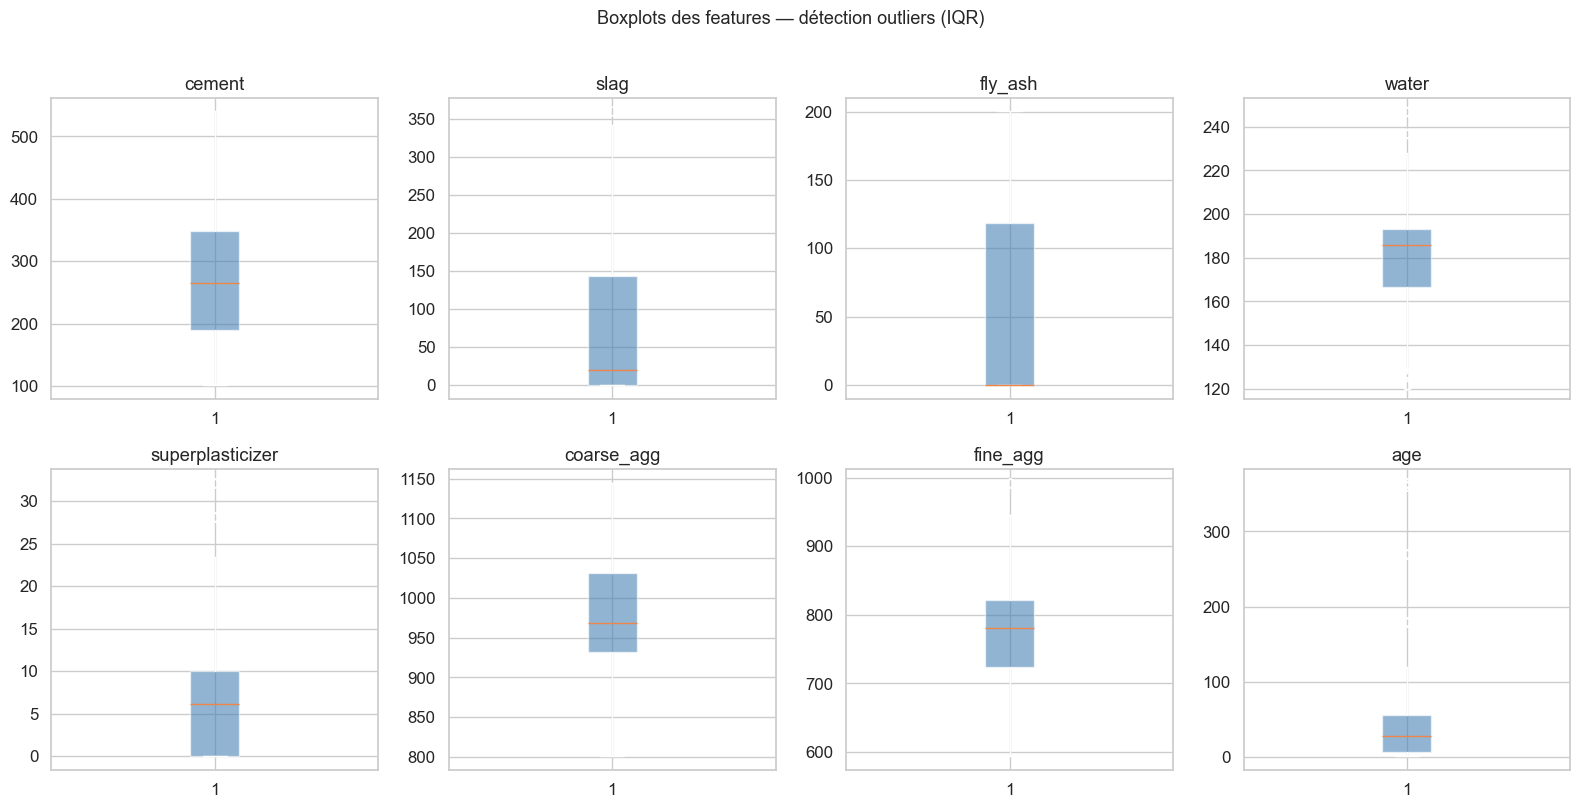

In [13]:
features = [c for c in df.columns if c != 'strength']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots des features — détection outliers (IQR)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :**  
- Les features `superplasticizer`, `slag`, `fly_ash` présentent des distributions très **asymétriques** avec une forte proportion de zéros (un béton peut ne pas contenir ces adjuvants). Ces zéros ne sont **pas des outliers**, ils sont physiquement valides.
- Les valeurs extrêmes détectées par IQR sont conservées : elles correspondent à des formulations de béton légitimes (haute performance ou très basiques).
- **Décision** : pas de suppression d'outliers. Le `StandardScaler` du Pipeline centrera/normalisera toutes les features, ce qui limite l'impact des valeurs extrêmes.

---
## 3. Analyse Exploratoire (EDA)

L'EDA vise à comprendre la structure des données **avant de choisir les algorithmes**.
On cherche : la distribution de la cible, les corrélations, et les patterns entre features.

### 3.1 Statistiques descriptives

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1005.000,278.629,104.345,102.000,190.680,265.000,349.000,540.000
slag,1005.000,72.043,86.171,0.000,0.000,20.000,142.500,359.400
fly_ash,1005.000,55.535,64.207,0.000,0.000,0.000,118.270,200.100
water,1005.000,182.074,21.341,121.750,166.610,185.700,192.940,247.000
superplasticizer,1005.000,6.032,5.920,0.000,0.000,6.100,10.000,32.200
coarse_agg,1005.000,974.376,77.580,801.000,932.000,968.000,1031.000,1145.000
fine_agg,1005.000,772.687,80.340,594.000,724.300,780.000,822.200,992.600
age,1005.000,45.857,63.735,1.000,7.000,28.000,56.000,365.000
strength,1005.000,35.250,16.285,2.332,23.524,33.798,44.868,82.599


**Interprétation :**  
- **`strength`** (target) : moyenne ~35 MPa, std ~16 MPa, range [2, 82] MPa — forte variabilité → bonne distribution pour la régression.
- **`age`** : distribution très asymétrique (min 1 jour, max 365 jours, median ~28 jours) → les jeunes bétons sont sur-représentés.
- **`superplasticizer`, `slag`, `fly_ash`** : min=0, indiquant que ces composants sont absents dans plusieurs formulations.
- Les features ont des **échelles très différentes** (cement ~200-500, water ~100-250, age 1-365) → le `StandardScaler` est **indispensable** pour les algorithmes sensibles aux échelles (Ridge, etc.).

### 3.2 Distribution de la variable cible

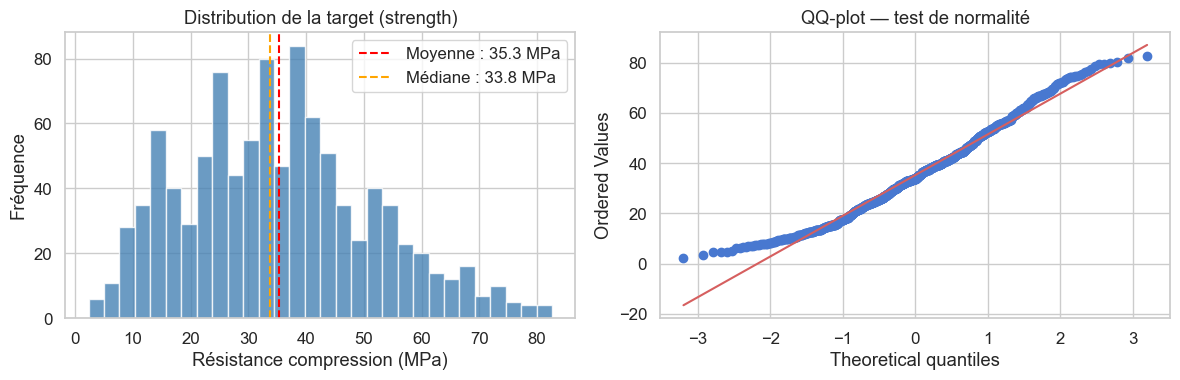

Skewness : 0.396
Kurtosis : -0.305


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(df['strength'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['strength'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['strength'].mean():.1f} MPa")
axes[0].axvline(df['strength'].median(), color='orange', linestyle='--', label=f"Médiane : {df['strength'].median():.1f} MPa")
axes[0].set_xlabel('Résistance compression (MPa)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la target (strength)')
axes[0].legend()

# QQ-plot
stats.probplot(df['strength'], dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot — test de normalité')

plt.tight_layout()
plt.show()

skewness = df['strength'].skew()
print(f'Skewness : {skewness:.3f}')
print(f'Kurtosis : {df["strength"].kurtosis():.3f}')

**Interprétation :**  
- La distribution de `strength` est **légèrement asymétrique à droite** (skewness > 0) avec une queue vers les hautes résistances (bétons haute performance).
- Elle n'est pas parfaitement normale (QQ-plot montre des déviations aux extrêmes), mais c'est acceptable pour nos méthodes de régression.
- On utilise le **MSE/RMSE** comme métrique d'évaluation (adapté à cette distribution, et cohérent avec la synthèse `4_Evaluation_de_performance.md`).

### 3.3 Distribution des features

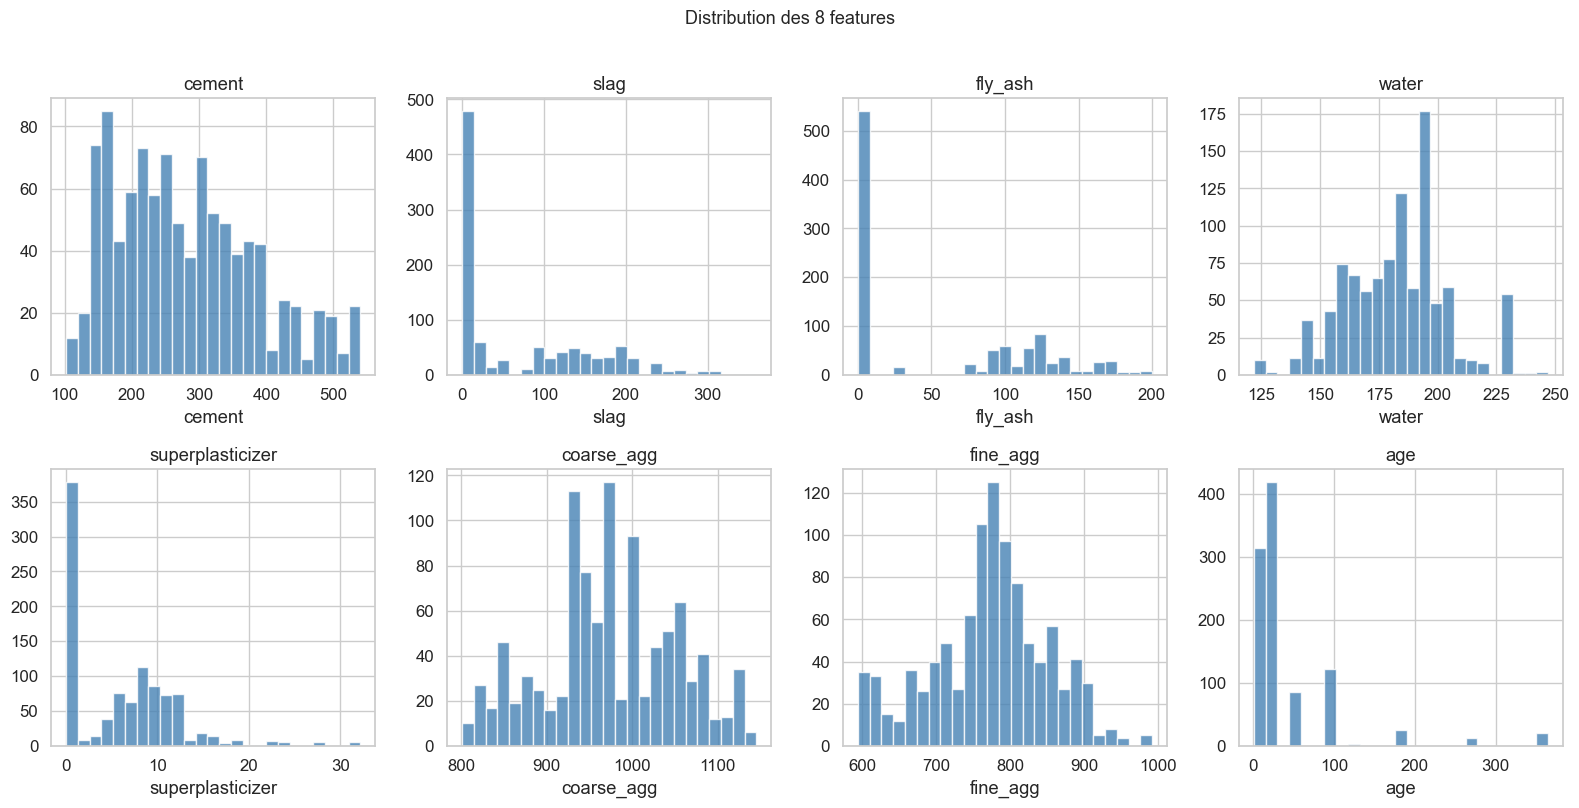

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

plt.suptitle('Distribution des 8 features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :**  
- **`slag`, `fly_ash`, `superplasticizer`** : distributions bimodales avec un pic à 0. Ces adjuvants sont souvent absents des mélanges standard → les modèles devront gérer cette bi-modalité.
- **`age`** : très asymétrique, dominé par les tests à 28 jours (standard industriel).
- **`cement`, `water`, `coarse_agg`, `fine_agg`** : distributions plus régulières, proches d'une uniforme ou normale.

### 3.4 Corrélations avec la cible

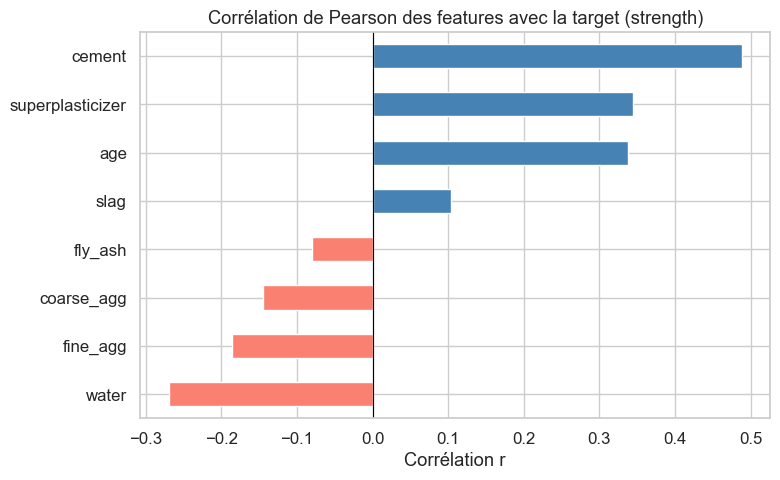

water              -0.270
fine_agg           -0.186
coarse_agg         -0.145
fly_ash            -0.081
slag                0.103
age                 0.337
superplasticizer    0.344
cement              0.488
Name: strength, dtype: float64


In [17]:
corr_with_target = df.corr()['strength'].drop('strength').sort_values()

colors = ['salmon' if c < 0 else 'steelblue' for c in corr_with_target]

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Corrélation de Pearson des features avec la target (strength)')
plt.xlabel('Corrélation r')
plt.tight_layout()
plt.show()

print(corr_with_target.round(3))

**Interprétation :**  
- **`cement`** (r ≈ +0.50) : corrélation positive forte — plus de ciment → béton plus résistant. ✅ Cohérent physiquement.
- **`age`** (r ≈ +0.33) : plus le béton vieillit, plus il durcit. ✅ Cohérent (hydratation progressive).
- **`superplasticizer`** (r ≈ +0.37) : adjuvant réducteur d'eau → améliore la résistance.
- **`water`** (r ≈ -0.29) : trop d'eau dilue le mélange → réduit la résistance. ✅ Loi eau/ciment de Feret.
- **`fine_agg`, `coarse_agg`** : corrélations faibles → rôle plus de remplissage que de résistance.

> Ces corrélations sont **non-linéaires en réalité** (loi eau/ciment exponentielle) — ce qui justifie d'utiliser **Random Forest et Gradient Boosting** qui capturent les non-linéarités, en plus de **Ridge** comme baseline linéaire.

### 3.5 Matrice de corrélation (heatmap)

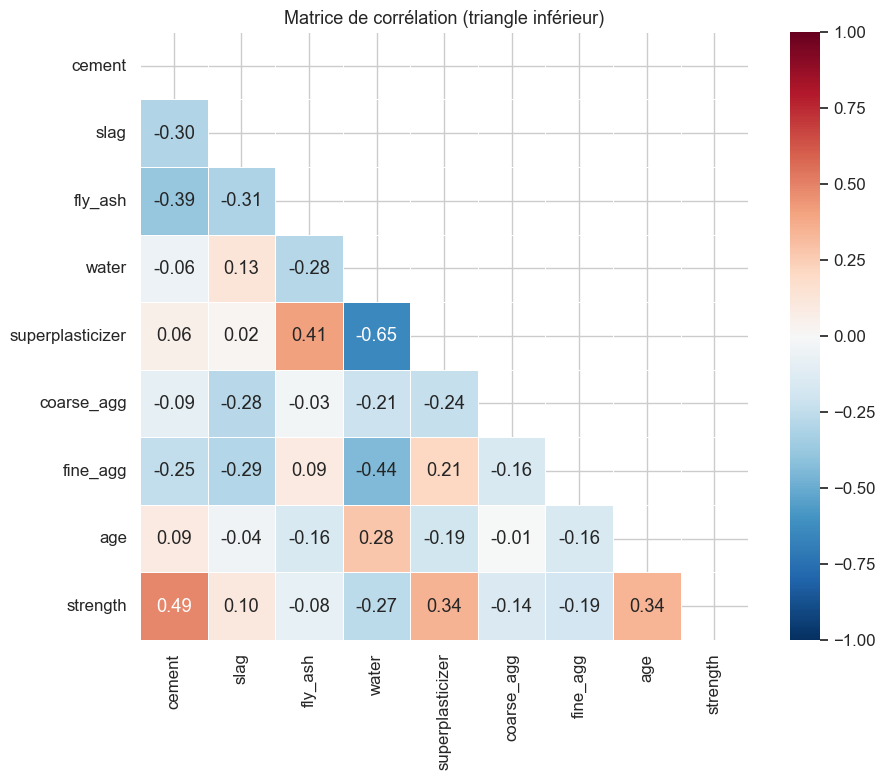

In [18]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title('Matrice de corrélation (triangle inférieur)', fontsize=13)
plt.tight_layout()
plt.show()

**Interprétation :**  
- **`superplasticizer` ↔ `water`** (r ≈ -0.66) : forte corrélation négative — quand on ajoute un plastifiant, on réduit l'eau. Physiquement logique. Attention à la **multicolinéarité** pour Ridge.
- **`fine_agg` ↔ `water`** (r ≈ -0.45) : corrélation modérée.
- Pas de corrélation > 0.8 entre features → pas de multicolinéarité critique, Ridge reste viable.
- Les arbres (Random Forest, Gradient Boosting) ne sont **pas affectés par la multicolinéarité** — avantage supplémentaire.

### 3.6 Scatterplots features vs target

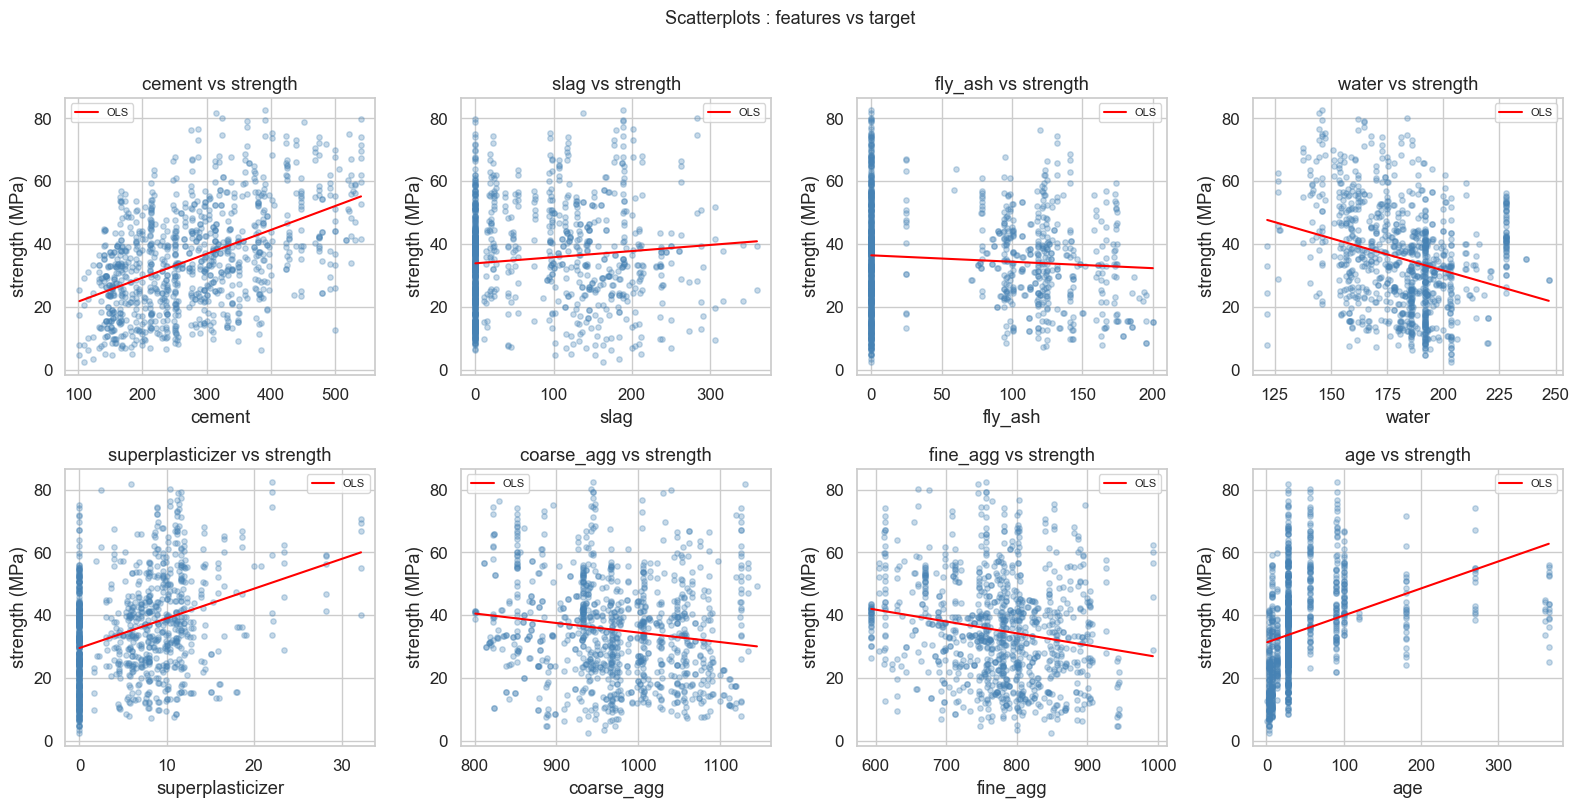

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['strength'], alpha=0.3, s=15, color='steelblue')
    # Ligne de régression linéaire simple pour référence
    m, b = np.polyfit(df[col], df['strength'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='OLS')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('strength (MPa)')
    axes[i].set_title(f'{col} vs strength')
    axes[i].legend(fontsize=8)

plt.suptitle('Scatterplots : features vs target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :**  
- **`cement` vs `strength`** : relation positive, mais nuage dispersé → non-linéarité présente.
- **`age` vs `strength`** : relation non-linéaire évidente (progression logarithmique typique de l'hydratation).
- **`water` vs `strength`** : tendance négative, mais avec forte dispersion.
- La plupart des relations sont **non-linéaires** → les modèles basés sur des arbres (Random Forest, Gradient Boosting) seront probablement supérieurs à Ridge sur ce dataset.

---
## 4. Préparation finale — X et y

On sépare les features de la cible. **Le dataset nettoyé est exporté** pour être utilisé dans le Notebook 2.

> **Important** : aucun StandardScaler, aucun imputer, aucune normalisation ici.  
> Tout le preprocessing sera encapsulé dans les **Pipelines sklearn** du Notebook 2 pour garantir l'**absence de data leakage**.

In [20]:
X = df.drop(columns=['strength'])
y = df['strength']

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'\nFeatures : {list(X.columns)}')
print(f'Target   : strength (MPa)')
print(f'\nMoyenne target  : {y.mean():.2f} MPa')
print(f'Std target      : {y.std():.2f} MPa')
print(f'Range target    : [{y.min():.2f}, {y.max():.2f}] MPa')

X shape : (1005, 8)
y shape : (1005,)

Features : ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']
Target   : strength (MPa)

Moyenne target  : 35.25 MPa
Std target      : 16.28 MPa
Range target    : [2.33, 82.60] MPa


In [21]:
# Export du dataset nettoyé
df.to_csv('../../data/concrete_clean.csv', index=False)
print('Dataset nettoyé sauvegardé → data/concrete_clean.csv')
print(f'Observations : {len(df)} (après suppression doublons)')

Dataset nettoyé sauvegardé → data/concrete_clean.csv
Observations : 1005 (après suppression doublons)


---
## Résumé du Notebook 1

| Étape | Résultat |
|---|---|
| Valeurs manquantes | 0 (dataset propre) |
| Doublons supprimés | à vérifier à l'exécution |
| Types de données | Tous numériques — OK |
| Outliers | Conservés (valeurs physiquement valides) |
| Feature la plus corrélée | `cement` (r ≈ +0.50) |
| Feature à corrélation négative | `water` (r ≈ -0.29) |
| Relations non-linéaires | Oui — justifie RF et GB en Notebook 2 |

**→ Notebook 2** : construction des 3 pipelines sklearn + nested cross-validation complète.